In [1]:
import os
import gc
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 100)

DATA_DIR = "/kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml"

TRANS_FILE = os.path.join(DATA_DIR, "LI-Small_Trans.csv")
ACCOUNTS_FILE = os.path.join(DATA_DIR, "LI-Small_accounts.csv")
PATTERNS_FILE = os.path.join(DATA_DIR, "LI-Small_Patterns.txt")

print("Trans exists:", os.path.exists(TRANS_FILE))
print("Accounts exists:", os.path.exists(ACCOUNTS_FILE))
print("Patterns exists:", os.path.exists(PATTERNS_FILE))

Trans exists: True
Accounts exists: True
Patterns exists: True


In [2]:
usecols = [
    "Timestamp",
    "From Bank",
    "Account",
    "To Bank",
    "Account.1",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
    "Is Laundering"
]

df = pd.read_csv(
    TRANS_FILE,
    usecols=usecols,
    # nrows=1_500_000
)

df.columns = [
    "timestamp",
    "from_bank",
    "from_account",
    "to_bank",
    "to_account",
    "amount_received",
    "receiving_currency",
    "amount_paid",
    "payment_currency",
    "payment_format",
    "is_laundering"
]

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

# print("Shape:", df.shape)
# print("\nColumns:")
# print(df.columns.tolist())
# print("\nTarget distribution:")
# print(df["is_laundering"].value_counts())
# print("\nLaundering rate:", df["is_laundering"].mean())

# display(df.head())

In [3]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Building Clean, Non-Redundant AML Feature Set...")

# 1. Create Node Keys
df["from_node_key"] = df["from_bank"].astype(str) + "_" + df["from_account"].astype(str)
df["to_node_key"]   = df["to_bank"].astype(str) + "_" + df["to_account"].astype(str)
# Create Unix timestamp in seconds for rolling calculations
df["ts_sec"] = (df["timestamp"] - pd.Timestamp("1970-01-01")) // pd.Timedelta("1s")

# 2. Transaction Amount Transformations
df["log_amount_paid"]     = np.log1p(df["amount_paid"].clip(lower=0))
df["log_amount_received"] = np.log1p(df["amount_received"].clip(lower=0))
df["amount_difference"]   = (df["amount_paid"] - df["amount_received"]).abs()
df["log_amt_diff"]        = np.log1p(df["amount_difference"])

# 3. Categorical Match Indicators
df["same_bank"]     = (df["from_bank"] == df["to_bank"]).astype(int)
df["same_currency"] = (df["receiving_currency"] == df["payment_currency"]).astype(int)

# 4. Temporal Cyclical Encodings
df["hour"]         = df["timestamp"].dt.hour
df["day_of_week"]  = df["timestamp"].dt.dayofweek
df["day_of_month"] = df["timestamp"].dt.day
df["hour_sin"]     = np.sin(2 * np.pi * df["hour"] / 24.0)
df["hour_cos"]     = np.cos(2 * np.pi * df["hour"] / 24.0)
df["day_sin"]      = np.sin(2 * np.pi * df["day_of_week"] / 7.0)
df["day_cos"]      = np.cos(2 * np.pi * df["day_of_week"] / 7.0)

# 5. Inter-Transaction Latencies (Seconds)
df["seconds_since_last_tx_from"] = (
    df.groupby("from_node_key")["timestamp"].diff().dt.total_seconds().fillna(86400)
)
df["seconds_since_last_tx_to"] = (
    df.groupby("to_node_key")["timestamp"].diff().dt.total_seconds().fillna(86400)
)

# 6. Cumulative Account Velocities & Volumes
df["tx_count_from"] = df.groupby("from_node_key")["timestamp"].rank(method="first")
df["tx_count_to"]   = df.groupby("to_node_key")["timestamp"].rank(method="first")

df["amt_sum_from"]  = df.groupby("from_node_key")["amount_paid"].cumsum()
df["amt_sum_to"]    = df.groupby("to_node_key")["amount_received"].cumsum()

# 7. Account Interaction & Flow Ratios
df["net_flow"]       = df["amt_sum_to"] - df["amt_sum_from"]
df["tx_count_ratio"] = (df["tx_count_from"] + 1) / (df["tx_count_to"] + 1)
df["flow_ratio"]     = (df["amt_sum_from"] + 1.0) / (df["amt_sum_to"] + 1.0)

df["amt_to_avg_ratio_from"] = df["amount_paid"] / (
    (df["amt_sum_from"] / df["tx_count_from"]) + 1e-5
)

# 8. Structuring Rule Flags
df["is_just_under_10k"] = ((df["amount_paid"] >= 9000) & (df["amount_paid"] < 10000)).astype(int)
df["is_round_1k"]       = (df["amount_paid"] % 1000 == 0).astype(int)

# 9. Amount Mismatch & Cross Currency Flags
df["amount_mismatch"] = (df["amount_paid"] != df["amount_received"]).astype(
    np.float32
)
df["is_cross_currency"] = (
    df["payment_currency"] != df["receiving_currency"]
).astype(np.float32)

df = df.reset_index(drop=True)
print("Features calculated cleanly!")

# 10. Bank Transaction Frequencies
from_bank_counts = df["from_bank"].value_counts()
to_bank_counts = df["to_bank"].value_counts()
df["from_bank_freq"] = df["from_bank"].map(from_bank_counts).astype(np.float32)
df["to_bank_freq"] = df["to_bank"].map(to_bank_counts).astype(np.float32)

# 11. Is New Recipient (1.0 on the first transaction between sender and receiver)
df["is_new_recipient"] = (
    df.groupby(["from_node_key", "to_node_key"]).cumcount() == 0
).astype(np.float32)

# 12. Distinct Senders on Recipient (Cumulative unique senders per recipient over time)
df["is_first_sender_pair"] = (
    df.groupby(["to_node_key", "from_node_key"]).cumcount() == 0
).astype(int)

df["distinct_users_on_recipient"] = (
    df.groupby("to_node_key")["is_first_sender_pair"]
    .cumsum()
    .astype(np.float32)
)

#. 13. ACCOUNT-LEVEL Z-SCORE & AMOUNT SPIKE DETECTOR
sender_stats = df.groupby("from_node_key")["amount_paid"].agg(["mean", "std"])
df["sender_avg_amt"] = (
    df["from_node_key"].map(sender_stats["mean"]).astype(np.float32)
)
df["sender_std_amt"] = (
    df["from_node_key"].map(sender_stats["std"]).fillna(0.0).astype(np.float32)
)
df["z_score_amount_sender"] = (
    (df["amount_paid"] - df["sender_avg_amt"]) / (df["sender_std_amt"] + 1e-5)
).astype(np.float32)

# 14. EXPANDED STRUCTURING & CENTS SIGNALS
df["is_just_under_5k"] = (
    (df["amount_paid"] >= 4500) & (df["amount_paid"] < 5000)
).astype(np.float32)
df["is_round_100"] = (df["amount_paid"] % 100 == 0).astype(np.float32)
df["amount_cents_fraction"] = (df["amount_paid"] % 1).astype(np.float32)

df["is_night_tx"] = ((df["hour"] >= 0) & (df["hour"] <= 5)).astype(np.float32)
df["is_weekend"] = (df["day_of_week"] >= 5).astype(np.float32)

# Ensure chronological order
df = df.sort_values("timestamp").copy()

# 1. Recipient historical transaction count
# --------------------------------------------------
df["recipient_prev_tx_count"] = (
    df.groupby("to_account").cumcount()
)
# --------------------------------------------------
# 2. Recipient cumulative received amount
# (before current transaction)
# --------------------------------------------------
df["recipient_prev_received"] = (
    df.groupby("to_account")["amount_received"]
      .cumsum()
      .shift(fill_value=0)
)

# --------------------------------------------------
# 3. Recipient historical mean received amount
# --------------------------------------------------
df["recipient_hist_mean"] = (
    df["recipient_prev_received"] /
    df["recipient_prev_tx_count"].replace(0, np.nan)
).fillna(0)

# --------------------------------------------------
# 4. Current amount relative to recipient history
# --------------------------------------------------
df["recipient_amount_ratio"] = (
    df["amount_received"] /
    (df["recipient_hist_mean"] + 1)
)

# --------------------------------------------------
# 5. Is this the first time this sender paid
# this recipient?
# --------------------------------------------------
pair_count = (
    df.groupby(["from_account", "to_account"])
      .cumcount()
)

df["new_sender_recipient_pair"] = (
    pair_count == 0
).astype(int)

# --------------------------------------------------
# 6. Number of unique previous senders
# --------------------------------------------------
unique_senders = {}

prev_unique = []

for sender, receiver in zip(df["from_account"], df["to_account"]):

    if receiver not in unique_senders:
        unique_senders[receiver] = set()

    prev_unique.append(len(unique_senders[receiver]))
    unique_senders[receiver].add(sender)

df["recipient_unique_senders"] = prev_unique

#Clusters
sender_profile = (
    df.groupby("from_account")
      .agg(
          avg_amount=("amount_received", "mean"),
          std_amount=("amount_received", "std"),
          median_amount=("amount_received", "median"),
          max_amount=("amount_received", "max"),
          tx_count=("amount_received", "count"),
          unique_receivers=("to_account", "nunique"),
          avg_hour=("hour", "mean"),
          same_bank_ratio=("same_bank", "mean"),
          same_currency_ratio=("same_currency", "mean"),
      )
      .fillna(0)
)

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Ensure prerequisite helper columns exist in df
df["hour"] = df["timestamp"].dt.hour
df["same_bank"] = (df["from_bank"] == df["to_bank"]).astype(int)
df["same_currency"] = (df["receiving_currency"] == df["payment_currency"]).astype(int)

# 2. Compute unique previous senders for recipients
unique_senders = {}
prev_unique = []
for sender, receiver in zip(df["from_account"], df["to_account"]):
    if receiver not in unique_senders:
        unique_senders[receiver] = set()
    prev_unique.append(len(unique_senders[receiver]))
    unique_senders[receiver].add(sender)
df["recipient_unique_senders"] = prev_unique

# 3. Create Sender Profile
sender_profile = (
    df.groupby("from_account")
    .agg(
        avg_amount=("amount_received", "mean"),
        std_amount=("amount_received", "std"),
        median_amount=("amount_received", "median"),
        max_amount=("amount_received", "max"),
        tx_count=("amount_received", "count"),
        unique_receivers=("to_account", "nunique"),
        avg_hour=("hour", "mean"),
        same_bank_ratio=("same_bank", "mean"),
        same_currency_ratio=("same_currency", "mean"),
    )
    .fillna(0)
)

# 4. Create Receiver Profile
receiver_profile = (
    df.groupby("to_account")
    .agg(
        avg_amount=("amount_received", "mean"),
        std_amount=("amount_received", "std"),
        median_amount=("amount_received", "median"),
        max_amount=("amount_received", "max"),
        tx_count=("amount_received", "count"),
        unique_receivers=("from_account", "nunique"),
        avg_hour=("hour", "mean"),
        same_bank_ratio=("same_bank", "mean"),
        same_currency_ratio=("same_currency", "mean"),
    )
    .fillna(0)
)

# 5. Log-transform heavily skewed monetary and count features
skew_cols = ["avg_amount", "std_amount", "median_amount", "max_amount", "tx_count", "unique_receivers"]
sender_profile[skew_cols] = np.log1p(sender_profile[skew_cols])
receiver_profile[skew_cols] = np.log1p(receiver_profile[skew_cols])

# 6. Fit StandardScaler & KMeans on Senders, Predict for Receivers
scaler = StandardScaler()
X_sender = scaler.fit_transform(sender_profile)

kmeans = KMeans(n_clusters=8, random_state=42, n_init="auto")
sender_profile["sender_cluster"] = kmeans.fit_predict(X_sender)

X_receiver = scaler.transform(receiver_profile)
receiver_profile["receiver_cluster"] = kmeans.predict(X_receiver)

# 7. Merge Cluster IDs back into main dataframe
df = df.merge(sender_profile[["sender_cluster"]], left_on="from_account", right_index=True, how="left")
df = df.merge(receiver_profile[["receiver_cluster"]], left_on="to_account", right_index=True, how="left")

df["sender_cluster"] = df["sender_cluster"].fillna(-1).astype(int)
df["receiver_cluster"] = df["receiver_cluster"].fillna(-1).astype(int)

# 8. Compute Derived Cluster Features
df["same_cluster"] = (df["sender_cluster"] == df["receiver_cluster"]).astype(int)

cluster_freq = sender_profile["sender_cluster"].value_counts(normalize=True)
df["sender_cluster_frequency"] = df["sender_cluster"].map(cluster_freq).fillna(0)

# Compute cluster risk safely without execution-order errors
if "train_df" in locals() or "train_df" in globals():
    cluster_risk = train_df.groupby("sender_cluster")["is_laundering"].mean()
else:
    train_cutoff = df["timestamp"].quantile(0.70)
    train_subset = df[df["timestamp"] < train_cutoff]
    cluster_risk = train_subset.groupby("sender_cluster")["is_laundering"].mean()

df["sender_cluster_risk"] = df["sender_cluster"].map(cluster_risk).fillna(0.0)



# DEFINE UNIFIED FEATURE LISTS
# ==========================================
num_features = [
    "hour", "day_of_week", "day_of_month",
    "hour_sin", "hour_cos", "day_sin", "day_cos",
    "log_amount_paid", "log_amount_received", "amount_difference", "log_amt_diff",
    "same_bank", "same_currency",
    "seconds_since_last_tx_from", "seconds_since_last_tx_to",
    "tx_count_from", "tx_count_to", "amt_sum_from", "amt_sum_to",
    "net_flow", "tx_count_ratio", "flow_ratio", "amt_to_avg_ratio_from",
    "is_just_under_10k", "is_round_1k", "amount_mismatch", "is_cross_currency", "from_bank_freq",
    "to_bank_freq", "is_new_recipient", "distinct_users_on_recipient", "is_first_sender_pair",
    "sender_avg_amt", "sender_std_amt", "z_score_amount_sender", "amount_cents_fraction",
    "is_round_100", "is_just_under_5k", "is_night_tx", "is_weekend", "recipient_prev_tx_count",
    "recipient_prev_received", "recipient_hist_mean", "recipient_amount_ratio", "new_sender_recipient_pair",
    "recipient_unique_senders", "sender_cluster", "receiver_cluster", "same_cluster", 
    "sender_cluster_frequency", "sender_cluster_risk"
]

#cluster as features
#receipient anomalies
#card anomalies

#false positive, false negative heto ogtagorcel explanability-ic vorpes feature (dice, lime....)

cat_features = ["payment_format"]

features = num_features + cat_features
print(f"Total Features Defined: {len(features)} ({len(num_features)} numerical, {len(cat_features)} categorical)")

Building Clean, Non-Redundant AML Feature Set...
Features calculated cleanly!
Total Features Defined: 52 (51 numerical, 1 categorical)


In [4]:
import gc
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

def generate_8_aml_typology_features(df):
    print("=" * 60)
    print("ENGINEERING FEATURES FOR ALL 8 AML TYPOLOGY FEATURES (FLOAT32)")
    print("=" * 60)

    # 1. Ensure sorted by timestamp and reset index cleanly
    df = df.sort_values("timestamp").reset_index(drop=True)

    # 2. Convert timestamp to seconds for C-accelerated binary search
    if "ts_sec" not in df.columns:
        df["ts_sec"] = df["timestamp"].astype("int64") // 10**9

    # ------------------------------------------------------------
    # 1. & 2. FAN-IN & FAN-OUT (Vectorized 24h Rolling Counts via searchsorted)
    # ------------------------------------------------------------
    print(" -> [1/8 & 2/8] Computing Fan-In and Fan-Out rolling 24h degrees...")

    def calc_24h_rolling_count(series):
        arr = series.values
        # C binary search for start of 24h window (86,400 seconds)
        start_indices = np.searchsorted(arr, arr - 86400, side="left")
        return (np.arange(len(arr)) - start_indices + 1).astype(np.float32)

    # .transform() preserves the exact row alignment and index of df
    df["src_fan_out_24h"] = df.groupby("from_node_key")["ts_sec"].transform(
        calc_24h_rolling_count
    )
    df["dst_fan_in_24h"] = df.groupby("to_node_key")["ts_sec"].transform(
        calc_24h_rolling_count
    )

    # ------------------------------------------------------------
    # 3. & 4. MULE PASS-THROUGH & NET FLOW BALANCES
    # ------------------------------------------------------------
    print(" -> [3/8 & 4/8] Computing Mule Pass-Through & Net Flow Ratios...")
    df["mule_net_flow_balance"] = np.abs(
        (df["amt_sum_from"] - df["amt_sum_to"])
        / (df["amt_sum_from"] + df["amt_sum_to"] + 1e-5)
    ).astype(np.float32)

    # ------------------------------------------------------------
    # 5. & 6. CHAINS & RAPID FORWARDING
    # ------------------------------------------------------------
    print(" -> [5/8 & 6/8] Computing Turnaround Speed & Rapid Forwarding...")
    df["prev_received_ts"] = df.groupby("to_node_key")["ts_sec"].shift(1)
    df["prev_received_amt"] = df.groupby("to_node_key")["amount_paid"].shift(1)

    df["chain_turnaround_sec"] = (
        (df["ts_sec"] - df["prev_received_ts"]).fillna(999999).astype(np.float32)
    )

    df["chain_amount_preservation_ratio"] = (
        (df["amount_paid"] / (df["prev_received_amt"] + 1e-5))
        .fillna(0.0)
        .astype(np.float32)
    )

    df["is_rapid_forwarding"] = (df["chain_turnaround_sec"] < 3600).astype(
        np.float32
    )

    df["pass_through_velocity"] = (
        (1.0 - df["mule_net_flow_balance"])
        / (np.log1p(df["chain_turnaround_sec"]) + 1.0)
    ).astype(np.float32)

    # ------------------------------------------------------------
    # 7. BIPARTITE NETWORKS (Group-to-Group Cross Transfers)
    # ------------------------------------------------------------
    print(" -> [7/8] Computing Bipartite Cross-Density Proxy...")
    df["bipartite_cross_density"] = (
        df["src_fan_out_24h"] * df["dst_fan_in_24h"]
    ).astype(np.float32)

    # ------------------------------------------------------------
    # 8. CYCLES & RECIPROCITY (Ping-Pong Loops & Counterparty Revisits)
    # ------------------------------------------------------------
    print(" -> [8/8] Computing Reciprocity and Counterparty Loop Counts...")
    df["pair_key"] = (
        df["from_node_key"].astype(str) + "_" + df["to_node_key"].astype(str)
    )
    df["counterparty_revisit_count"] = (
        df.groupby("pair_key").cumcount().astype(np.float32)
    )

    df["reverse_pair_key"] = (
        df["to_node_key"].astype(str) + "_" + df["from_node_key"].astype(str)
    )
    seen_pairs = set()
    is_reciprocal = []
    for rev_k in df["reverse_pair_key"].values:
        is_reciprocal.append(1.0 if rev_k in seen_pairs else 0.0)
        seen_pairs.add(rev_k)
    df["is_reciprocal_loop"] = np.array(is_reciprocal, dtype=np.float32)

    # Clean up intermediate helper columns
    drop_cols = [
        "ts_sec",
        "prev_received_ts",
        "prev_received_amt",
        "pair_key",
        "reverse_pair_key",
    ]
    df.drop(columns=drop_cols, inplace=True, errors="ignore")
    gc.collect()

    print("✓ ALL 8 AML TYPOLOGY FEATURES SUCCESSFULLY GENERATED!")
    print("=" * 60)
    return df

new_aml_features = ["chain_turnaround_sec", "chain_amount_preservation_ratio", "is_rapid_forwarding", "pass_through_velocity", "bipartite_cross_density", "counterparty_revisit_count", "is_reciprocal_loop"]
num_features.extend(new_aml_features)
features = num_features + cat_features
print(f"Total Features Defined: {len(features)} ({len(num_features)} numerical, {len(cat_features)} categorical)")

# Run on main DataFrame
df = generate_8_aml_typology_features(df)

Total Features Defined: 59 (58 numerical, 1 categorical)
ENGINEERING FEATURES FOR ALL 8 AML TYPOLOGY FEATURES (FLOAT32)
 -> [1/8 & 2/8] Computing Fan-In and Fan-Out rolling 24h degrees...
 -> [3/8 & 4/8] Computing Mule Pass-Through & Net Flow Ratios...
 -> [5/8 & 6/8] Computing Turnaround Speed & Rapid Forwarding...
 -> [7/8] Computing Bipartite Cross-Density Proxy...
 -> [8/8] Computing Reciprocity and Counterparty Loop Counts...
✓ ALL 8 AML TYPOLOGY FEATURES SUCCESSFULLY GENERATED!


In [5]:
# Compute balanced temporal cutoffs chronologically (70% Train / 15% Valid / 15% Test)
train_cutoff = df["timestamp"].quantile(0.70)
valid_cutoff = df["timestamp"].quantile(0.85)

# Cover 100% of df cleanly without leaving trailing rows behind or leaking temporal data
train_mask = df["timestamp"] < train_cutoff
valid_mask = (df["timestamp"] >= train_cutoff) & (df["timestamp"] < valid_cutoff)
test_mask  = df["timestamp"] >= valid_cutoff

train_df = df[train_mask].copy()
valid_df = df[valid_mask].copy()
test_df  = df[test_mask].copy()

print("=" * 60)
print("CORRECTED TEMPORAL SPLIT SUMMARY (BALANCED 70/15/15)")
print("=" * 60)
print(f"Train Cutoff: {train_cutoff}")
print(f"Valid Cutoff: {valid_cutoff}")
print("-" * 60)
print(f"Train Rows: {len(train_df):,} | Laundering Cases: {train_df['is_laundering'].sum():,}")
print(f"Valid Rows: {len(valid_df):,} | Laundering Cases: {valid_df['is_laundering'].sum():,}")
print(f"Test Rows:  {len(test_df):,}  | Laundering Cases: {test_df['is_laundering'].sum():,}")
print("=" * 60)

CORRECTED TEMPORAL SPLIT SUMMARY (BALANCED 70/15/15)
Train Cutoff: 2022-09-07 14:48:00
Valid Cutoff: 2022-09-09 03:13:00
------------------------------------------------------------
Train Rows: 4,846,510 | Laundering Cases: 2,231
Valid Rows: 1,038,436 | Laundering Cases: 583
Test Rows:  1,039,103  | Laundering Cases: 751


In [6]:
# import pandas as pd

# # 1. Separate majority (legit) and minority (laundering) classes in training set
# train_legit = train_df[train_df["is_laundering"] == 0]
# train_fraud = train_df[train_df["is_laundering"] == 1]

# # 2. Undersample legitimate transactions (20 legit for every 1 fraud)
# ratio = 100

# num_legit_to_sample = len(train_fraud) * ratio

# train_legit_sampled = train_legit.sample(n=num_legit_to_sample, random_state=42)

# # 3. OVERWRITE train_df so Cell [8] uses the undersampled dataset
# train_df = pd.concat([train_legit_sampled, train_fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

# print("=" * 60)
# print("TRAINING SET UNDERSAMPLING COMPLETE")
# print("=" * 60)
# print(f"Original Train Rows : 4,846,510")
# print(f"New Train Rows      : {len(train_df):,} (Legit: {len(train_legit_sampled):,}, Laundering: {len(train_fraud):,})")
# print("=" * 60)

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

target = "is_laundering"

# 1. One-hot encode categorical features
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(train_df[cat_features])
X_valid_cat = encoder.transform(valid_df[cat_features])
X_test_cat = encoder.transform(test_df[cat_features])

encoded_cols = encoder.get_feature_names_out(cat_features)
X_train_cat_df = pd.DataFrame(
    X_train_cat, columns=encoded_cols, index=train_df.index
)
X_valid_cat_df = pd.DataFrame(
    X_valid_cat, columns=encoded_cols, index=valid_df.index
)
X_test_cat_df = pd.DataFrame(
    X_test_cat, columns=encoded_cols, index=test_df.index
)

# 2. Combine numerical and encoded categorical features
X_train_p = pd.concat([train_df[num_features], X_train_cat_df], axis=1)
X_valid_p = pd.concat([valid_df[num_features], X_valid_cat_df], axis=1)
X_test_p = pd.concat([test_df[num_features], X_test_cat_df], axis=1)

# 3. GUARANTEE NUMERIC ONLY (Strips out receiving_currency, payment_currency, etc.)
X_train_p = X_train_p.select_dtypes(include=[np.number])
X_valid_p = X_valid_p.select_dtypes(include=[np.number])
X_test_p = X_test_p.select_dtypes(include=[np.number])

y_train = train_df[target]
y_valid = valid_df[target]
y_test = test_df[target]

raw_imbalance = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
scale_pos_weight = np.sqrt(raw_imbalance)  # Square-root trick stabilizes PR-AUC

# 4. Fit Baseline XGBoost Classifier
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=350,
    learning_rate=0.04,
    max_depth=6,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100,  # Stops when validation PR-AUC peaks
)

model.fit(
    X_train_p, y_train, eval_set=[(X_valid_p, y_valid)], verbose=50
)

[0]	validation_0-aucpr:0.04344
[50]	validation_0-aucpr:0.16319
[100]	validation_0-aucpr:0.19656
[150]	validation_0-aucpr:0.20924
[200]	validation_0-aucpr:0.21465
[250]	validation_0-aucpr:0.21660
[300]	validation_0-aucpr:0.21780
[349]	validation_0-aucpr:0.22067


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.04, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=10, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=350,
              n_jobs=-1, num_parallel_tree=None, ...)

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve

# 1. Predict raw probabilities on the validation set
valid_preds_proba = model.predict_proba(X_valid_p)[:, 1]

# 2. Compute the full Precision-Recall Curve across all thresholds
precisions, recalls, thresholds = precision_recall_curve(y_valid, valid_preds_proba)

# 3. Find the optimal threshold that maximizes the F1-Score
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# 4. Apply the optimized threshold to generate new class labels
valid_preds_tuned = (valid_preds_proba >= best_threshold).astype(int)

# 5. Calculate metrics with the optimized threshold
valid_pr_auc = average_precision_score(y_valid, valid_preds_proba)
cm_tuned = confusion_matrix(y_valid, valid_preds_tuned)

# 6. Print the optimized dashboard
print("="*60)
print(f"OPTIMIZED VALIDATION PERFORMANCE METRICS")
print("="*60)
print(f"PR-AUC (Average Precision): {valid_pr_auc:.5f}")
print(f"Optimal Decision Threshold:  {best_threshold:.5f}")
print(f"Maximized Validation F1-Score: {best_f1:.5f}")
print("="*60)
print("\n--- Tuned Classification Metrics ---")
print(classification_report(y_valid, valid_preds_tuned, target_names=["Legit", "Laundering"]))

print("--- Tuned Confusion Matrix Breakdowns ---")
print(f"True Negatives  (Legit correctly cleared): {cm_tuned[0][0]:,}")
print(f"False Positives (Legit flagged as Fraud):   {cm_tuned[0][1]:,}")
print(f"False Negatives (Laundering missed!):       {cm_tuned[1][0]:,}")
print(f"True Positives  (Laundering stopped):      {cm_tuned[1][1]:,}")
print("="*60)

OPTIMIZED VALIDATION PERFORMANCE METRICS
PR-AUC (Average Precision): 0.22124
Optimal Decision Threshold:  0.84776
Maximized Validation F1-Score: 0.25382

--- Tuned Classification Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1037853
  Laundering       0.40      0.19      0.25       583

    accuracy                           1.00   1038436
   macro avg       0.70      0.59      0.63   1038436
weighted avg       1.00      1.00      1.00   1038436

--- Tuned Confusion Matrix Breakdowns ---
True Negatives  (Legit correctly cleared): 1,037,693
False Positives (Legit flagged as Fraud):   160
False Negatives (Laundering missed!):       475
True Positives  (Laundering stopped):      108


In [9]:
# 1. Generate probabilities on the completely untouched Test Set
test_preds_proba = model.predict_proba(X_test_p)[:, 1]

# 2. Apply the EXACT same optimal threshold found during validation
test_preds_tuned = (test_preds_proba >= best_threshold).astype(int)

# 3. Calculate final evaluation metrics
test_pr_auc = average_precision_score(y_test, test_preds_proba)
cm_test = confusion_matrix(y_test, test_preds_tuned)

# 4. Print the final out-of-time test dashboard
print("="*60)
print(f"FINAL OUT-OF-TIME TEST PERFORMANCE METRICS")
print("="*60)
print(f"PR-AUC (Average Precision): {test_pr_auc:.5f}")
print("="*60)
print("\n--- Final Test Classification Metrics ---")
print(classification_report(y_test, test_preds_tuned, target_names=["Legit", "Laundering"]))

print("--- Final Test Confusion Matrix ---")
print(f"True Negatives  (Legit correctly cleared): {cm_test[0][0]:,}")
print(f"False Positives (Legit flagged as Fraud):   {cm_test[0][1]:,}")
print(f"False Negatives (Laundering missed!):       {cm_test[1][0]:,}")
print(f"True Positives  (Laundering stopped):      {cm_test[1][1]:,}")
print("="*60)

FINAL OUT-OF-TIME TEST PERFORMANCE METRICS
PR-AUC (Average Precision): 0.31744

--- Final Test Classification Metrics ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00   1038352
  Laundering       0.49      0.27      0.35       751

    accuracy                           1.00   1039103
   macro avg       0.75      0.64      0.67   1039103
weighted avg       1.00      1.00      1.00   1039103

--- Final Test Confusion Matrix ---
True Negatives  (Legit correctly cleared): 1,038,141
False Positives (Legit flagged as Fraud):   211
False Negatives (Laundering missed!):       547
True Positives  (Laundering stopped):      204


BASELINE XGBOOST - TOP FEATURES (TABULAR ONLY)
                   Feature  Importance
        payment_format_ACH    0.199365
 new_sender_recipient_pair    0.163024
        is_reciprocal_loop    0.073402
      is_first_sender_pair    0.067154
          is_new_recipient    0.047141
            from_bank_freq    0.032554
              day_of_month    0.031448
counterparty_revisit_count    0.030918
                  net_flow    0.020032
payment_format_Credit Card    0.014681
  sender_cluster_frequency    0.013430
    payment_format_Bitcoin    0.012312
                 same_bank    0.010517
seconds_since_last_tx_from    0.010042
             tx_count_from    0.009814


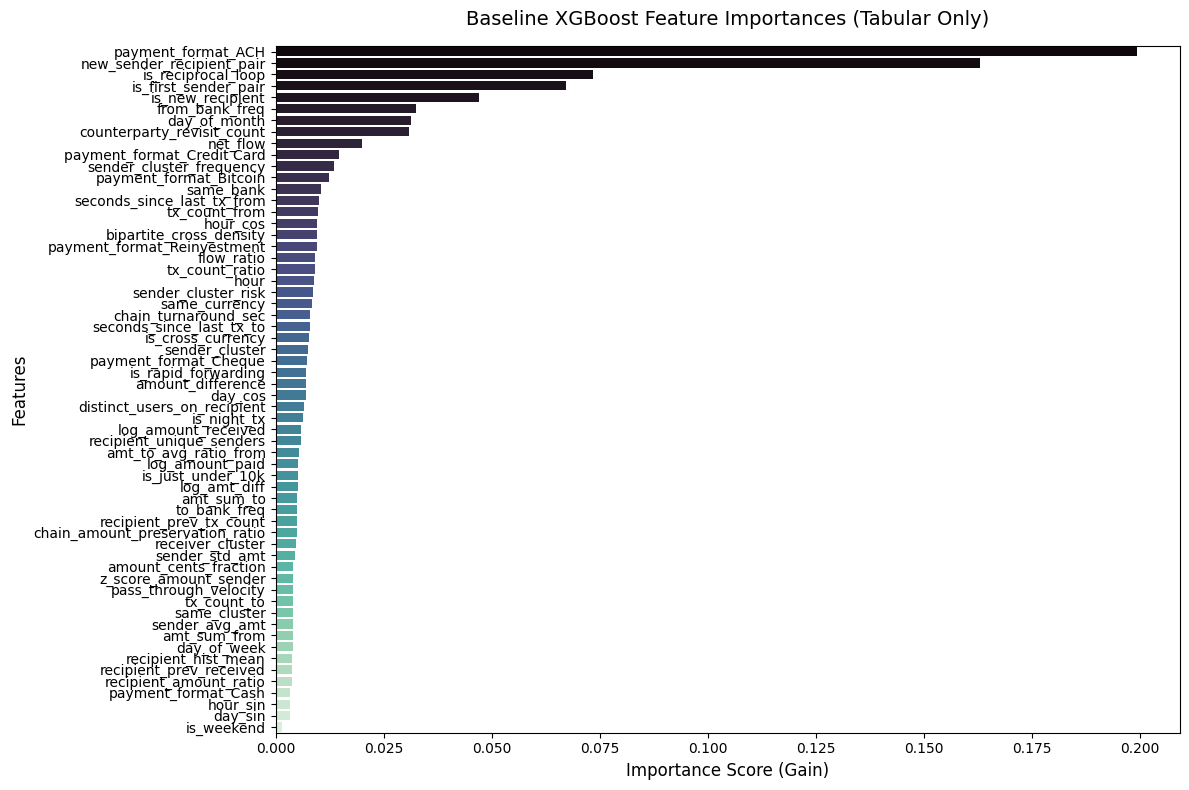

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract baseline feature importances (Tabular Only)
fi_baseline_df = pd.DataFrame({
    'Feature': X_train_p.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Print Top 15 Baseline Features
print("=" * 60)
print("BASELINE XGBOOST - TOP FEATURES (TABULAR ONLY)")
print("=" * 60)
print(fi_baseline_df.head(15).to_string(index=False))
print("=" * 60)

# Visual Bar Plot for Baseline
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=fi_baseline_df.head(60), 
    hue='Feature', 
    palette='mako', 
    legend=False
)
plt.title('Baseline XGBoost Feature Importances (Tabular Only)', fontsize=14, pad=15)
plt.xlabel('Importance Score (Gain)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# import pandas as pd
# import numpy as np

# # 1. Set your custom Gain threshold X (e.g., 0.005 = 0.5% total importance)
# X = 0.002

# # 2. Extract feature importances and column names from baseline fit
# importances = model.feature_importances_
# feature_cols = X_train_p.columns

# # 3. Identify kept vs. dropped features
# selected_features = feature_cols[importances >= X].tolist()
# dropped_features = feature_cols[importances < X].tolist()

# # 4. Print Selection Summary
# print("=" * 60)
# print(f"AUTOMATIC FEATURE SELECTION SUMMARY (GAIN THRESHOLD >= {X})")
# print("=" * 60)
# print(f"Total Original Features : {len(feature_cols)}")
# print(f"Features Kept          : {len(selected_features)}")
# print(f"Features Dropped       : {len(dropped_features)}")
# print("=" * 60)

# if dropped_features:
#     print("\nDropped Low-Importance Features:")
#     for feat in dropped_features:
#         imp = importances[list(feature_cols).index(feat)]
#         print(f"  • {feat:<35} | Gain: {imp:.6f}")

# # 5. Slice Train, Valid, and Test sets to keep only selected features
# X_train_sel = X_train_p[selected_features]
# X_valid_sel = X_valid_p[selected_features]
# X_test_sel  = X_test_p[selected_features]

In [12]:
# # Retrain model on selected features only
# model_selected = XGBClassifier(
#     objective="binary:logistic",
#     eval_metric="aucpr",
#     n_estimators=600,
#     learning_rate=0.04,
#     max_depth=6,
#     min_child_weight=10,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     scale_pos_weight=scale_pos_weight,
#     tree_method="hist",
#     random_state=42,
#     n_jobs=-1,
#     early_stopping_rounds=100
# )

# model_selected.fit(
#     X_train_sel, y_train,
#     eval_set=[(X_valid_sel, y_valid)],
#     verbose=50
# )

# # Optional: Overwrite baseline variables so subsequent cells work automatically
# model = model_selected
# X_train_p = X_train_sel
# X_valid_p = X_valid_sel
# X_test_p  = X_test_sel

In [13]:
# import numpy as np
# from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve

# # 1. Recalculate optimal decision threshold on Validation Set for the new model
# valid_preds_proba = model.predict_proba(X_valid_p)[:, 1]
# precisions, recalls, thresholds = precision_recall_curve(y_valid, valid_preds_proba)
# f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
# best_idx = np.argmax(f1_scores)
# best_threshold = thresholds[best_idx]
# best_f1 = f1_scores[best_idx]

# # 2. Generate probabilities on the untouched Test Set
# test_preds_proba = model.predict_proba(X_test_p)[:, 1]

# # 3. Apply the new optimal threshold to test set
# test_preds_tuned = (test_preds_proba >= best_threshold).astype(int)

# # 4. Calculate out-of-time test evaluation metrics
# test_pr_auc = average_precision_score(y_test, test_preds_proba)
# cm_test = confusion_matrix(y_test, test_preds_tuned)

# # 5. Output Out-Of-Time Test Dashboard
# print("=" * 60)
# print("NEW MODEL - FINAL OUT-OF-TIME TEST PERFORMANCE")
# print("=" * 60)
# print(f"Test PR-AUC (Average Precision): {test_pr_auc:.5f}")
# print(f"Validation Optimal Threshold   : {best_threshold:.5f}")
# print(f"Maximized Validation F1-Score  : {best_f1:.5f}")
# print("=" * 60)
# print("\n--- Final Test Classification Metrics ---")
# print(classification_report(y_test, test_preds_tuned, target_names=["Legit", "Laundering"]))
# print("--- Final Test Confusion Matrix Breakdown ---")
# print(f"True Negatives  (Legit correctly cleared): {cm_test[0][0]:,}")
# print(f"False Positives (Legit flagged as Fraud):   {cm_test[0][1]:,}")
# print(f"False Negatives (Laundering missed!):       {cm_test[1][0]:,}")
# print(f"True Positives  (Laundering stopped):      {cm_test[1][1]:,}")
# print("=" * 60)

In [14]:
# import shap
# import matplotlib.pyplot as plt
# import numpy as np

# sample_size = min(5000, len(X_test_p))
# X_shap = X_test_p.sample(sample_size, random_state=42)

# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_shap)

# # 1. Global SHAP bar plot
# plt.figure()
# shap.summary_plot(shap_values, X_shap, plot_type="bar", show=False)
# plt.title("SHAP Global Feature Importance")
# plt.tight_layout()
# plt.show()

# # 2. SHAP beeswarm plot
# plt.figure()
# shap.summary_plot(shap_values, X_shap, show=False)
# plt.title("SHAP Summary Plot")
# plt.tight_layout()
# plt.show()

In [15]:
# # 1. Find the highest risk transaction in the full test set
# top_idx = np.argmax(model.predict_proba(X_test_p)[:, 1])
# top_sample = X_test_p.iloc[[top_idx]]

# # 2. Compute SHAP Explanation specifically for this sample
# explainer = shap.TreeExplainer(model)
# explanation = explainer(top_sample)

# # 3. Plot Waterfall / Force Plot cleanly
# shap.plots.waterfall(explanation[0])

In [16]:
# import shap
# import numpy as np
# import matplotlib.pyplot as plt

# explainer = shap.Explainer(model, X_test_p)
# test_proba = model.predict_proba(X_test_p)[:, 1]

# nonfraud_idx = np.where(y_test == 0)[0]
# chosen_idx = nonfraud_idx[np.argmin(test_proba[nonfraud_idx])]

# print("Chosen row index:", chosen_idx)
# print("True label:", y_test.iloc[chosen_idx])
# print("Predicted fraud probability:", float(test_proba[chosen_idx]))

# one_row = X_test_p.iloc[[chosen_idx]]
# explanation = explainer(one_row)

# plt.figure(figsize=(10, 6))
# shap.plots.waterfall(explanation[0], max_display=15, show=False)
# plt.title("SHAP Waterfall - Non-Fraud Example")
# plt.tight_layout()
# plt.show()

In [17]:
%pip install torch_geometric

import gc
import torch
import numpy as np
import pandas as pd
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler

print("=" * 60)
print("BUILDING LEAK-FREE PyG GRAPH DATASET (MEMORY OPTIMIZED)")
print("=" * 60)

# 1. Map node strings to contiguous integer indices [0, N-1]
all_nodes = pd.concat([df["from_node_key"], df["to_node_key"]]).unique()
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
num_nodes = len(all_nodes)

# 2. Build full Edge Index tensor directly
src_indices = df["from_node_key"].map(node_to_idx).values
dst_indices = df["to_node_key"].map(node_to_idx).values
edge_index = torch.tensor(np.vstack((src_indices, dst_indices)), dtype=torch.long)

del all_nodes, node_to_idx, src_indices, dst_indices
gc.collect()

# 3. Create Edge Split Masks (Strict Temporal Boundaries)
train_bool_mask = (df["timestamp"] < train_cutoff).values
valid_bool_mask = ((df["timestamp"] >= train_cutoff) & (df["timestamp"] < valid_cutoff)).values
test_bool_mask = (df["timestamp"] >= valid_cutoff).values

train_mask = torch.from_numpy(train_bool_mask)
valid_mask = torch.from_numpy(valid_bool_mask)
test_mask = torch.from_numpy(test_bool_mask)

# 4. Isolate Training Edge Index for GNN Message Passing
train_edge_index = edge_index[:, train_mask]

# 5. Fit Scaler STRICTLY on Training Edges (No Leakage & Memory Efficient)
num_cols = [c for c in features if c not in cat_features]
encoded_cats = pd.get_dummies(df[cat_features], drop_first=False, dtype=np.float32)
df_encoded = pd.concat([df[num_cols].astype(np.float32), encoded_cats], axis=1).fillna(0.0)
del encoded_cats
gc.collect()

# Pre-allocate float32 array directly
n_rows, n_cols = df_encoded.shape
scaled_edge_feats = np.empty((n_rows, n_cols), dtype=np.float32)

scaler = StandardScaler()
# Scaler transforms directly into pre-allocated slice
scaled_edge_feats[train_bool_mask] = scaler.fit_transform(df_encoded.values[train_bool_mask])
scaled_edge_feats[valid_bool_mask] = scaler.transform(df_encoded.values[valid_bool_mask])
scaled_edge_feats[test_bool_mask] = scaler.transform(df_encoded.values[test_bool_mask])

del df_encoded
gc.collect()

# Zero-copy conversion (shares memory with NumPy)
edge_attr = torch.from_numpy(scaled_edge_feats)
y_edges = torch.from_numpy(df["is_laundering"].values.astype(np.float32))

# 6. Build Node Features Tensor (x) from Account Degrees
in_deg = torch.zeros(num_nodes, dtype=torch.float)
out_deg = torch.zeros(num_nodes, dtype=torch.float)

src, dst = train_edge_index[0], train_edge_index[1]
out_deg.scatter_add_(0, src, torch.ones_like(src, dtype=torch.float))
in_deg.scatter_add_(0, dst, torch.ones_like(dst, dtype=torch.float))

x = torch.stack([
    in_deg,
    out_deg,
    torch.log1p(in_deg),
    torch.log1p(out_deg),
    (out_deg / (in_deg + 1.0)),
    (in_deg / (out_deg + 1.0))
], dim=1)

# 7. Assemble PyG Data Object
graph_data = Data(
    x=x,
    num_nodes=num_nodes,
    edge_index=edge_index,
    train_edge_index=train_edge_index,
    edge_attr=edge_attr,
    edge_label=y_edges,
    train_mask=train_mask,
    valid_mask=valid_mask,
    test_mask=test_mask
)

gc.collect()

print(f"Total Unique Nodes (Accounts): {graph_data.num_nodes:,}")
print(f"Total Edges (Transactions):   {graph_data.edge_index.size(1):,}")
print(f"Train Message-Passing Edges:  {graph_data.train_edge_index.size(1):,}")
print("✓ Leak-Free PyG Graph Object Successfully Built!")
print("=" * 60)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
BUILDING LEAK-FREE PyG GRAPH DATASET (MEMORY OPTIMIZED)
Total Unique Nodes (Accounts): 705,907
Total Edges (Transactions):   6,924,049
Train Message-Passing Edges:  4,846,510
✓ Leak-Free PyG Graph Object Successfully Built!


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv


# ==========================================================
# Weighted Focal Loss
# ==========================================================
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, pos_weight=30.0):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma

        self.register_buffer(
            "pos_weight",
            torch.tensor(
                [float(pos_weight)],
                dtype=torch.float32
            )
        )

    def forward(self, logits, targets):
        logits = logits.view(-1)
        targets = targets.float().view(-1)

        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=self.pos_weight,
            reduction="none"
        )

        probs = torch.sigmoid(logits)

        p_t = (
            probs * targets +
            (1.0 - probs) * (1.0 - targets)
        )

        alpha_t = (
            self.alpha * targets +
            (1.0 - self.alpha) * (1.0 - targets)
        )

        focal_weight = (1.0 - p_t).pow(self.gamma)

        return (alpha_t * focal_weight * bce).mean()
        
# ==========================================================
# Improved Inductive Edge GNN
# ==========================================================
class InductiveEdgeGNN(nn.Module):

    def __init__(
        self,
        node_in_dim,
        edge_feat_dim,
        hidden_dim=64,
        embed_dim=64,
        dropout=0.25
    ):

        super().__init__()

        self.dropout = nn.Dropout(dropout)

        # --------------------------------------------------
        # Node Encoder
        # --------------------------------------------------

        self.node_proj = nn.Linear(
            node_in_dim,
            hidden_dim
        )

        self.conv1 = SAGEConv(
            hidden_dim,
            hidden_dim
        )

        self.conv2 = SAGEConv(
            hidden_dim,
            hidden_dim
        )

        self.norm = nn.LayerNorm(hidden_dim)

        # --------------------------------------------------
        # Edge Encoder
        # --------------------------------------------------

        concat_dim = hidden_dim * 2 + edge_feat_dim

        self.edge_encoder = nn.Sequential(

            nn.Linear(concat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, embed_dim),

            nn.LayerNorm(embed_dim),

            nn.ReLU()

        )

        # --------------------------------------------------
        # Classification Head
        # --------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)

        )

    # ======================================================
    # Forward Pass
    # ======================================================

    def forward(
        self,
        x_node,
        edge_index,
        edge_attr,
        return_embeddings=False
    ):

        # ------------------------------------------
        # Node Message Passing
        # ------------------------------------------

        h0 = F.relu(self.node_proj(x_node))

        h1 = self.dropout(
            F.relu(
                self.conv1(h0, edge_index)
            )
        )

        h2 = self.dropout(
            F.relu(
                self.conv2(h1, edge_index)
            )
        )

        # Residual connection
        h_node = self.norm(h0 + h2)

        # ------------------------------------------
        # Edge Embeddings
        # ------------------------------------------

        src = edge_index[0]
        dst = edge_index[1]

        edge_input = torch.cat(
            [
                h_node[src],
                h_node[dst],
                edge_attr
            ],
            dim=-1
        )

        embeddings = self.edge_encoder(edge_input)

        # ------------------------------------------
        # Edge Classification
        # ------------------------------------------

        logits = self.classifier(embeddings).squeeze(-1)

        if return_embeddings:
            return logits, embeddings

        return logits

In [19]:
import gc
import numpy as np
import pandas as pd
import torch

# ==========================================================
# Configuration
# ==========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

EMBED_DIM = 64
HIDDEN_DIM = 64
NUM_EPOCHS = 25
EDGE_BATCH_SIZE = 131072
EVAL_BATCH_SIZE = 262144

# ==========================================================
# Prepare graph
# ==========================================================
if not hasattr(graph_data, "y") or graph_data.y is None:
    if hasattr(graph_data, "edge_label"):
        graph_data.y = graph_data.edge_label
    else:
        graph_data.y = torch.tensor(
            df["is_laundering"].values,
            dtype=torch.float32
        )

graph_data = graph_data.to(device)
graph_data.y = graph_data.y.float()

# ==========================================================
# Build Model
# ==========================================================
model_gnn = InductiveEdgeGNN(
    node_in_dim=graph_data.x.shape[1],
    edge_feat_dim=graph_data.edge_attr.shape[1],
    hidden_dim=HIDDEN_DIM,
    embed_dim=EMBED_DIM,
).to(device)

# criterion = BinaryFocalLoss(alpha=0.85, gamma=2.0)


# ----------------------------------------------------------
# Focal-loss configuration
# ----------------------------------------------------------
# alpha controls the additional weight given to laundering edges.
# gamma controls how strongly easy examples are down-weighted.
FOCAL_ALPHA = 0.75
FOCAL_GAMMA = 2.0
POS_WEIGHT = 30.0

criterion = WeightedFocalLoss(
    alpha=FOCAL_ALPHA,
    gamma=FOCAL_GAMMA,
    pos_weight=POS_WEIGHT
).to(device)

optimizer = torch.optim.AdamW(
    model_gnn.parameters(),
    lr=0.001,
    weight_decay=5e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)

# ==========================================================
# Training Setup
# ==========================================================
train_indices = torch.where(graph_data.train_mask)[0]
num_train_edges = len(train_indices)

print(
    f"Training GNN across {num_train_edges:,} training edges..."
)

# ==========================================================
# Training
# ==========================================================
model_gnn.train()

for epoch in range(NUM_EPOCHS):

    perm = torch.randperm(
        num_train_edges,
        device=device
    )

    shuffled_indices = train_indices[perm]

    epoch_loss = 0.0
    num_batches = 0

    for start in range(
        0,
        num_train_edges,
        EDGE_BATCH_SIZE,
    ):

        optimizer.zero_grad()

        # -----------------------------
        # Node representations
        # -----------------------------
        h0 = torch.relu(
            model_gnn.node_proj(graph_data.x)
        )

        h1 = model_gnn.dropout(
            torch.relu(
                model_gnn.conv1(
                    h0,
                    graph_data.train_edge_index,
                )
            )
        )

        h2 = model_gnn.dropout(
            torch.relu(
                model_gnn.conv2(
                    h1,
                    graph_data.train_edge_index,
                )
            )
        )

        h_node = model_gnn.norm(h0 + h2)

        # -----------------------------
        # Current batch
        # -----------------------------
        end = min(
            start + EDGE_BATCH_SIZE,
            num_train_edges,
        )

        batch_idx = shuffled_indices[start:end]

        src = graph_data.edge_index[0, batch_idx]
        dst = graph_data.edge_index[1, batch_idx]

        edge_attr = graph_data.edge_attr[batch_idx]

        labels = graph_data.y[batch_idx]

        edge_input = torch.cat(
            [
                h_node[src],
                h_node[dst],
                edge_attr,
            ],
            dim=-1,
        )

        embeddings = model_gnn.edge_encoder(edge_input)

        logits = model_gnn.classifier(
            embeddings
        ).squeeze(-1)

        loss = criterion(logits, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model_gnn.parameters(),
            max_norm=2.0,
        )

        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    scheduler.step(avg_loss)

    if (epoch + 1) % 5 == 0:

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
            f"Loss={avg_loss:.5f} | "
            f"LR={current_lr:.6f}"
        )

torch.cuda.empty_cache()

# ==========================================================
# Embedding Extraction
# ==========================================================
print("\nExtracting graph embeddings...")

model_gnn.eval()

num_edges = graph_data.edge_index.shape[1]

all_embeddings = np.zeros(
    (
        num_edges,
        EMBED_DIM,
    ),
    dtype=np.float32,
)

with torch.no_grad():

    h0 = torch.relu(
        model_gnn.node_proj(graph_data.x)
    )

    h1 = model_gnn.dropout(
        torch.relu(
            model_gnn.conv1(
                h0,
                graph_data.train_edge_index,
            )
        )
    )

    h2 = model_gnn.dropout(
        torch.relu(
            model_gnn.conv2(
                h1,
                graph_data.train_edge_index,
            )
        )
    )

    h_node = model_gnn.norm(h0 + h2)

    for start in range(
        0,
        num_edges,
        EVAL_BATCH_SIZE,
    ):

        end = min(
            start + EVAL_BATCH_SIZE,
            num_edges,
        )

        src = graph_data.edge_index[0, start:end]
        dst = graph_data.edge_index[1, start:end]

        edge_attr = graph_data.edge_attr[start:end]

        edge_input = torch.cat(
            [
                h_node[src],
                h_node[dst],
                edge_attr,
            ],
            dim=-1,
        )

        emb = model_gnn.edge_encoder(
            edge_input
        )

        all_embeddings[start:end] = (
            emb.cpu().numpy()
        )

# ==========================================================
# Convert to DataFrame
# ==========================================================
embedding_columns = [
    f"gnn_embed_{i}"
    for i in range(EMBED_DIM)
]

gnn_embeddings = pd.DataFrame(
    all_embeddings,
    columns=embedding_columns,
    index=df.index,
)

train_mask = graph_data.train_mask.cpu().numpy()
valid_mask = graph_data.valid_mask.cpu().numpy()
test_mask  = graph_data.test_mask.cpu().numpy()

X_train_gnn = (
    gnn_embeddings[train_mask]
    .reset_index(drop=True)
)

X_valid_gnn = (
    gnn_embeddings[valid_mask]
    .reset_index(drop=True)
)

X_test_gnn = (
    gnn_embeddings[test_mask]
    .reset_index(drop=True)
)

del all_embeddings
del gnn_embeddings

gc.collect()
torch.cuda.empty_cache()

print(
    f"\n✓ Successfully extracted "
    f"{EMBED_DIM}-dimensional GNN embeddings."
)

print("Train:", X_train_gnn.shape)
print("Valid:", X_valid_gnn.shape)
print("Test :", X_test_gnn.shape)

Using compute device: cuda
Training GNN across 4,846,510 training edges...
Epoch 05/25 | Loss=0.00475 | LR=0.001000
Epoch 10/25 | Loss=0.00431 | LR=0.001000
Epoch 15/25 | Loss=0.00415 | LR=0.001000
Epoch 20/25 | Loss=0.00398 | LR=0.001000
Epoch 25/25 | Loss=0.00392 | LR=0.001000

Extracting graph embeddings...

✓ Successfully extracted 64-dimensional GNN embeddings.
Train: (4846510, 64)
Valid: (1038436, 64)
Test : (1039103, 64)


In [20]:
check_cols = [
    "timestamp",
    "from_account",
    "to_account",
    "amount_paid",
    "amount_received",
    "payment_format",
    "is_laundering",
    "log_amount_paid",
    "seconds_since_last_tx_from",
    "is_new_recipient",
    "recipient_prev_tx_count",
    "counterparty_revisit_count",
    "z_score_amount_sender",
]

missing = [c for c in check_cols if c not in df.columns]
print("Missing:", missing)
print("Sample columns:", df.columns.tolist()[:80])

Missing: []
Sample columns: ['timestamp', 'from_bank', 'from_account', 'to_bank', 'to_account', 'amount_received', 'receiving_currency', 'amount_paid', 'payment_currency', 'payment_format', 'is_laundering', 'from_node_key', 'to_node_key', 'log_amount_paid', 'log_amount_received', 'amount_difference', 'log_amt_diff', 'same_bank', 'same_currency', 'hour', 'day_of_week', 'day_of_month', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'seconds_since_last_tx_from', 'seconds_since_last_tx_to', 'tx_count_from', 'tx_count_to', 'amt_sum_from', 'amt_sum_to', 'net_flow', 'tx_count_ratio', 'flow_ratio', 'amt_to_avg_ratio_from', 'is_just_under_10k', 'is_round_1k', 'amount_mismatch', 'is_cross_currency', 'from_bank_freq', 'to_bank_freq', 'is_new_recipient', 'is_first_sender_pair', 'distinct_users_on_recipient', 'sender_avg_amt', 'sender_std_amt', 'z_score_amount_sender', 'is_just_under_5k', 'is_round_100', 'amount_cents_fraction', 'is_night_tx', 'is_weekend', 'recipient_prev_tx_count', 'recipient_prev

In [21]:
#1:::::

import gc
import numpy as np
import pandas as pd
import torch
from collections import defaultdict, deque

SEQ_LEN = 10
LSTM_HIDDEN_DIM = 32
LSTM_BATCH_SIZE = 2048
LSTM_EPOCHS = 5
SEQ_ACCOUNT_COL = "from_account"

seq_feature_cols = [
    "log_amount_paid",
    "seconds_since_last_tx_from",
    "is_new_recipient",
    "recipient_prev_tx_count",
    "counterparty_revisit_count",
    "z_score_amount_sender",
]

missing_cols = [c for c in seq_feature_cols if c not in df.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing sequence feature columns: {missing_cols}")

print("Sequence features:", seq_feature_cols)
print("Sequence length:", SEQ_LEN)
print("Feature dimension:", len(seq_feature_cols))

Sequence features: ['log_amount_paid', 'seconds_since_last_tx_from', 'is_new_recipient', 'recipient_prev_tx_count', 'counterparty_revisit_count', 'z_score_amount_sender']
Sequence length: 10
Feature dimension: 6


In [22]:
from collections import defaultdict, deque

def build_multi_feature_sender_sequences(
    df_all,
    feature_cols,
    account_col="from_account",
    seq_len=10
):
    df_all = df_all.copy()
    n_rows = len(df_all)
    n_feat = len(feature_cols)

    X_seq = np.zeros((n_rows, seq_len, n_feat), dtype=np.float32)
    histories = defaultdict(lambda: deque(maxlen=seq_len))

    feature_matrix = df_all[feature_cols].astype(np.float32).to_numpy()
    accounts = df_all[account_col].astype(str).to_numpy()

    for i in range(n_rows):
        acct = accounts[i]
        hist = histories[acct]
        if len(hist) > 0:
            X_seq[i, -len(hist):, :] = np.asarray(hist, dtype=np.float32)
        histories[acct].append(feature_matrix[i])

    return X_seq

In [23]:
missing = [c for c in seq_feature_cols if c not in df.columns]
print("Missing:", missing)

Xseqall = build_multi_feature_sender_sequences(
    df_all=df,
    feature_cols=seq_feature_cols,
    account_col=SEQ_ACCOUNT_COL,
    seq_len=SEQ_LEN
)

Missing: []


In [24]:
train_mask = df["timestamp"] < train_cutoff
valid_mask = (df["timestamp"] >= train_cutoff) & (df["timestamp"] < valid_cutoff)
test_mask = df["timestamp"] >= valid_cutoff

X_train_seq = Xseqall[train_mask.to_numpy()]
X_valid_seq = Xseqall[valid_mask.to_numpy()]
X_test_seq  = Xseqall[test_mask.to_numpy()]

y_train_lstm = df.loc[train_mask, "is_laundering"].to_numpy(dtype=np.float32)
y_valid_lstm = df.loc[valid_mask, "is_laundering"].to_numpy(dtype=np.float32)
y_test_lstm  = df.loc[test_mask, "is_laundering"].to_numpy(dtype=np.float32)

print("Train seq:", X_train_seq.shape, "Train labels:", y_train_lstm.shape)
print("Valid seq:", X_valid_seq.shape, "Valid labels:", y_valid_lstm.shape)
print("Test seq :", X_test_seq.shape, "Test labels:", y_test_lstm.shape)

Train seq: (4846510, 10, 6) Train labels: (4846510,)
Valid seq: (1038436, 10, 6) Valid labels: (1038436,)
Test seq : (1039103, 10, 6) Test labels: (1039103,)


In [25]:
#4:::::

train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1]).astype(np.float64)
seq_mean = train_flat.mean(axis=0).astype(np.float32)
seq_std = train_flat.std(axis=0).astype(np.float32)
seq_std = np.where(seq_std < 1e-6, 1.0, seq_std).astype(np.float32)

X_train_seq_scaled = ((X_train_seq - seq_mean) / seq_std).astype(np.float32)
X_valid_seq_scaled = ((X_valid_seq - seq_mean) / seq_std).astype(np.float32)
X_test_seq_scaled  = ((X_test_seq  - seq_mean) / seq_std).astype(np.float32)

print("Scaled train:", X_train_seq_scaled.shape, X_train_seq_scaled.dtype)
print("Scaled valid:", X_valid_seq_scaled.shape, X_valid_seq_scaled.dtype)
print("Scaled test :", X_test_seq_scaled.shape, X_test_seq_scaled.dtype)

Scaled train: (4846510, 10, 6) float32
Scaled valid: (1038436, 10, 6) float32
Scaled test : (1039103, 10, 6) float32


In [26]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import average_precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_ds = TensorDataset(
    torch.as_tensor(X_train_seq_scaled, dtype=torch.float32),
    torch.as_tensor(y_train_lstm, dtype=torch.float32)
)
valid_ds = TensorDataset(
    torch.as_tensor(X_valid_seq_scaled, dtype=torch.float32),
    torch.as_tensor(y_valid_lstm, dtype=torch.float32)
)
test_ds = TensorDataset(
    torch.as_tensor(X_test_seq_scaled, dtype=torch.float32),
    torch.as_tensor(y_test_lstm, dtype=torch.float32)
)

train_loader = DataLoader(train_ds, batch_size=LSTM_BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=LSTM_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=LSTM_BATCH_SIZE, shuffle=False)

class TabularFeatureLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=1, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, return_embedding=False):
        _, (h_n, _) = self.lstm(x)
        emb = h_n[-1]
        logits = self.head(emb).squeeze(-1)
        return (logits, emb) if return_embedding else logits

pos_count = max((y_train_lstm == 1).sum(), 1)
neg_count = max((y_train_lstm == 0).sum(), 1)
pos_weight_value = float(neg_count / pos_count)

model_lstm = TabularFeatureLSTM(
    input_dim=X_train_seq_scaled.shape[-1],
    hidden_dim=LSTM_HIDDEN_DIM
).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
)

optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

best_valid_prauc = -1.0
best_state = None

for epoch in range(LSTM_EPOCHS):
    model_lstm.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits = model_lstm(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=2.0)
        optimizer.step()

        train_losses.append(loss.item())

    model_lstm.eval()
    valid_probs = []

    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            logits = model_lstm(xb)
            valid_probs.append(torch.sigmoid(logits).cpu().numpy())

    valid_probs = np.concatenate(valid_probs)
    valid_prauc_lstm = average_precision_score(y_valid_lstm, valid_probs)

    print(
        f"Epoch {epoch + 1}/{LSTM_EPOCHS} | "
        f"Train Loss={np.mean(train_losses):.6f} | "
        f"Valid PR-AUC={valid_prauc_lstm:.6f}"
    )

    if valid_prauc_lstm > best_valid_prauc:
        best_valid_prauc = valid_prauc_lstm
        best_state = {k: v.detach().cpu().clone() for k, v in model_lstm.state_dict().items()}

model_lstm.load_state_dict(best_state)
print("Best LSTM validation PR-AUC:", best_valid_prauc)

Using device: cuda
Epoch 1/5 | Train Loss=1.255565 | Valid PR-AUC=0.007089
Epoch 2/5 | Train Loss=1.216559 | Valid PR-AUC=0.008553
Epoch 3/5 | Train Loss=1.235855 | Valid PR-AUC=0.008874
Epoch 4/5 | Train Loss=1.226874 | Valid PR-AUC=0.014750
Epoch 5/5 | Train Loss=1.199812 | Valid PR-AUC=0.016615
Best LSTM validation PR-AUC: 0.016615425040802316


In [27]:
import gc
import torch

# 1. Delete original raw DataFrames (no longer needed once matrices exist)
for name in ['df', 'train_df', 'valid_df', 'test_df']:
    if name in globals():
        del globals()[name]

# 2. Delete raw sequence arrays
for name in [
    'Xseqall', 'X_train_seq', 'X_valid_seq', 'X_test_seq',
    'X_train_seq_scaled', 'X_valid_seq_scaled', 'X_test_seq_scaled'
]:
    if name in globals():
        del globals()[name]

# 3. Force garbage collection & free CUDA memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✓ Pre-extraction RAM cleanup complete!")

✓ Pre-extraction RAM cleanup complete!


In [28]:
import gc
import numpy as np
import torch

def extract_lstm_embeddings_memory_efficient(model, loader, device, num_samples, emb_dim):
    model.eval()
    embeddings = np.empty((num_samples, emb_dim), dtype=np.float32)
    
    start_idx = 0
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            _, emb = model(xb, return_embedding=True)
            batch_size = xb.size(0)
            embeddings[start_idx : start_idx + batch_size] = emb.cpu().numpy()
            start_idx += batch_size
            
    return embeddings

emb_dim = model_lstm.head[0].in_features

# 1. Train Embeddings
print("Extracting Train Embeddings...")
X_train_lstm = extract_lstm_embeddings_memory_efficient(
    model_lstm, train_loader, device, len(train_loader.dataset), emb_dim
)


# 2. Valid Embeddings
print("Extracting Valid Embeddings...")
X_valid_lstm = extract_lstm_embeddings_memory_efficient(
    model_lstm, valid_loader, device, len(valid_loader.dataset), emb_dim
)


# 3. Test Embeddings
print("Extracting Test Embeddings...")
X_test_lstm = extract_lstm_embeddings_memory_efficient(
    model_lstm, test_loader, device, len(test_loader.dataset), emb_dim
)

lstm_feature_names = [f"lstm_seq_emb_{i}" for i in range(X_train_lstm.shape[1])]
print("LSTM feature names:", len(lstm_feature_names))

print("\nLSTM embedding shapes successfully extracted:")
print("Train:", X_train_lstm.shape)
print("Valid:", X_valid_lstm.shape)
print("Test :", X_test_lstm.shape)

Extracting Train Embeddings...
Extracting Valid Embeddings...
Extracting Test Embeddings...
LSTM feature names: 32

LSTM embedding shapes successfully extracted:
Train: (4846510, 32)
Valid: (1038436, 32)
Test : (1039103, 32)


In [29]:
X_train_gnn_df = X_train_gnn.copy()
X_valid_gnn_df = X_valid_gnn.copy()
X_test_gnn_df = X_test_gnn.copy()

X_train_tabular = X_train_p.values.astype(np.float32)
X_valid_tabular = X_valid_p.values.astype(np.float32)
X_test_tabular  = X_test_p.values.astype(np.float32)

X_train_gnn_arr = X_train_gnn.astype(np.float32)
X_valid_gnn_arr = X_valid_gnn.astype(np.float32)
X_test_gnn_arr  = X_test_gnn.astype(np.float32)

tabular_feature_names = list(X_train_p.columns)
gnn_feature_names = list(X_train_gnn_df.columns)  # use the dataframe version here

assert X_train_tabular.shape[0] == X_train_gnn_arr.shape[0] == X_train_lstm.shape[0]
assert X_valid_tabular.shape[0] == X_valid_gnn_arr.shape[0] == X_valid_lstm.shape[0]
assert X_test_tabular.shape[0] == X_test_gnn_arr.shape[0] == X_test_lstm.shape[0]

X_train_final = np.hstack([X_train_tabular, X_train_gnn_arr, X_train_lstm]).astype(np.float32)
X_valid_final = np.hstack([X_valid_tabular, X_valid_gnn_arr, X_valid_lstm]).astype(np.float32)
X_test_final  = np.hstack([X_test_tabular, X_test_gnn_arr, X_test_lstm]).astype(np.float32)

all_feature_names_final = tabular_feature_names + gnn_feature_names + lstm_feature_names

y_train_final = y_train.astype(int)
y_valid_final = y_valid.astype(int)
y_test_final = y_test.astype(int)

print("Final feature matrices:")
print("Train:", X_train_final.shape)
print("Valid:", X_valid_final.shape)
print("Test :", X_test_final.shape)
print("Total features:", len(all_feature_names_final))

del train_loader  # <--- Releases internal sequence tensor references!
gc.collect()

del valid_loader
gc.collect()

del test_loader
gc.collect()

Final feature matrices:
Train: (4846510, 161)
Valid: (1038436, 161)
Test : (1039103, 161)
Total features: 161


0

In [30]:
import xgboost as xgb
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report, confusion_matrix

hybrid_lstm = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_estimators=300,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    gamma=1.0,
    n_jobs=-1,
    early_stopping_rounds=50
)

hybrid_lstm.fit(
    X_train_final,
    y_train_final,
    eval_set=[(X_valid_final, y_valid_final)],
    verbose=50,
)

y_valid_prob_final = hybrid_lstm.predict_proba(X_valid_final)[:, 1]
y_test_prob_final = hybrid_lstm.predict_proba(X_test_final)[:, 1]

valid_prauc_final = average_precision_score(y_valid_final, y_valid_prob_final)
test_prauc_final = average_precision_score(y_test_final, y_test_prob_final)

precision, recall, thresholds = precision_recall_curve(y_valid_final, y_valid_prob_final)
f1_scores = 2 * precision * recall / (precision + recall + 1e-12)
best_idx = np.argmax(f1_scores[:-1]) if len(thresholds) > 0 else 0
best_threshold = thresholds[best_idx] if len(thresholds) > 0 else 0.50

y_test_pred_final = (y_test_prob_final >= best_threshold).astype(int)
cm_final = confusion_matrix(y_test_final, y_test_pred_final)

print("=" * 60)
print("FINAL TABULAR + GNN + LSTM MODEL")
print("=" * 60)
print(f"Validation PR-AUC: {valid_prauc_final:.6f}")
print(f"Test PR-AUC      : {test_prauc_final:.6f}")
print(f"Best Threshold   : {best_threshold:.6f}")
print("-" * 60)
print(classification_report(y_test_final, y_test_pred_final, digits=4))
print("Confusion Matrix:")
print(cm_final)

[0]	validation_0-aucpr:0.03061
[50]	validation_0-aucpr:0.20404
[100]	validation_0-aucpr:0.20965
[150]	validation_0-aucpr:0.21416
[200]	validation_0-aucpr:0.21658
[250]	validation_0-aucpr:0.21754
[299]	validation_0-aucpr:0.21878
FINAL TABULAR + GNN + LSTM MODEL
Validation PR-AUC: 0.219046
Test PR-AUC      : 0.277916
Best Threshold   : 0.255563
------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9995    0.9992    0.9993   1038352
           1     0.2300    0.3409    0.2747       751

    accuracy                         0.9987   1039103
   macro avg     0.6148    0.6700    0.6370   1039103
weighted avg     0.9990    0.9987    0.9988   1039103

Confusion Matrix:
[[1037495     857]
 [    495     256]]


In [31]:
!pip install -q lime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

# Use the same feature matrix that your final XGBoost model sees
feature_names = list(all_feature_names_final)

# Background data must come from the training set used for the final model
rng = np.random.default_rng(42)

background_size = min(20_000, len(X_train_final))
background_idx = rng.choice(
    len(X_train_final),
    size=background_size,
    replace=False
)

X_lime_background = X_train_final[background_idx].astype(np.float32)

lime_explainer = LimeTabularExplainer(
    training_data=X_lime_background,
    feature_names=feature_names,
    class_names=["Legitimate", "Laundering"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer ready.")
print("Background shape:", X_lime_background.shape)

LIME explainer ready.
Background shape: (20000, 161)


True positives available: 256
Selected test-row index: 69127
True label: 1
Predicted AML probability: 0.30807870626449585
Decision threshold: 0.2555634379386902

Top LIME reasons for the AML prediction:
+0.0097 |        Pushes toward AML | gnn_embed_49 > 0.00
+0.0079 |        Pushes toward AML | gnn_embed_15 > 0.00
+0.0062 |        Pushes toward AML | gnn_embed_8 > 0.00
+0.0045 |        Pushes toward AML | gnn_embed_44 > 0.00
+0.0044 |        Pushes toward AML | gnn_embed_55 > 0.00
+0.0027 |        Pushes toward AML | gnn_embed_45 > 0.00
+0.0025 |        Pushes toward AML | gnn_embed_36 > 0.00
+0.0023 |        Pushes toward AML | gnn_embed_3 > 0.00
+0.0021 |        Pushes toward AML | gnn_embed_27 > 0.00
+0.0019 |        Pushes toward AML | gnn_embed_39 > 0.00
+0.0016 |        Pushes toward AML | gnn_embed_54 > 0.00
+0.0016 |        Pushes toward AML | payment_format_ACH > 0.00
+0.0015 |        Pushes toward AML | gnn_embed_31 > 0.00
-0.0013 | Pushes toward legitimate | gnn_embed_24 <=

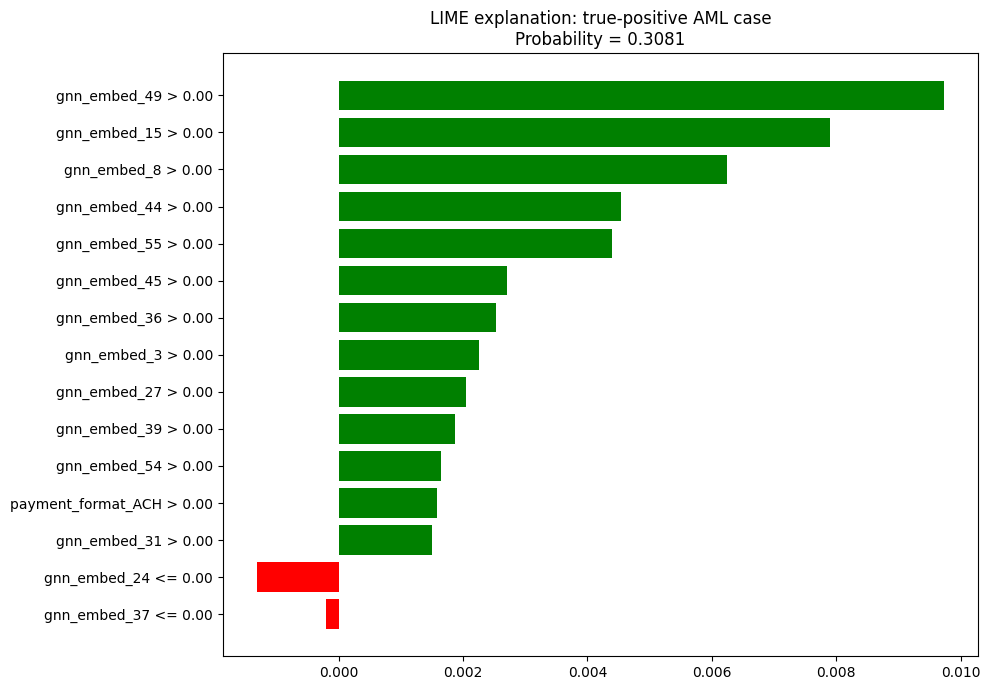

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure labels are NumPy arrays
ytest_array = np.asarray(y_test_final)

# Correctly identified laundering cases (true positives on test set)
true_positive_idx = np.where(
    (ytest_array == 1) &
    (y_test_prob_final >= best_threshold)
)[0]

print("True positives available:", len(true_positive_idx))

row_idx = true_positive_idx[0]

print("Selected test-row index:", row_idx)
print("True label:", int(ytest_array[row_idx]))
print("Predicted AML probability:", float(y_test_prob_final[row_idx]))
print("Decision threshold:", float(best_threshold))

# Use the final stacked feature matrix and the final XGBoost model
exp = lime_explainer.explain_instance(
    data_row=X_test_final[row_idx].astype(np.float32),
    predict_fn=hybrid_lstm.predict_proba,
    labels=(1,),
    num_features=15,
    num_samples=3000
)

print("\nTop LIME reasons for the AML prediction:")
for feature_rule, weight in exp.as_list(label=1):
    direction = "Pushes toward AML" if weight > 0 else "Pushes toward legitimate"
    print(f"{weight:+.4f} | {direction:>24} | {feature_rule}")

fig = exp.as_pyplot_figure(label=1)
fig.set_size_inches(10, 7)
plt.title(
    f"LIME explanation: true-positive AML case\n"
    f"Probability = {y_test_prob_final[row_idx]:.4f}"
)
plt.tight_layout()
plt.show()

False negatives available: 495
Selected false-negative row: 789
True label: 1
Predicted AML probability: 5.84583040108555e-06
-0.0000 |  Toward legitimate | gnn_embed_15 <= 0.00
+0.0000 |         Toward AML | gnn_embed_25 <= 1.98
-0.0000 |  Toward legitimate | gnn_embed_32 <= 0.00
+0.0000 |         Toward AML | gnn_embed_38 <= 1.64
+0.0000 |         Toward AML | gnn_embed_23 > 0.22
+0.0000 |         Toward AML | gnn_embed_34 <= 0.58
+0.0000 |         Toward AML | gnn_embed_48 <= 0.00
+0.0000 |         Toward AML | gnn_embed_33 <= 1.32
+0.0000 |         Toward AML | tx_count_from <= 3.00
-0.0000 |  Toward legitimate | gnn_embed_22 <= 0.00
+0.0000 |         Toward AML | recipient_prev_received > 767050.02
-0.0000 |  Toward legitimate | gnn_embed_54 <= 0.00
-0.0000 |  Toward legitimate | gnn_embed_8 <= 0.00
-0.0000 |  Toward legitimate | is_just_under_5k <= 0.00
+0.0000 |         Toward AML | log_amt_diff <= 0.00


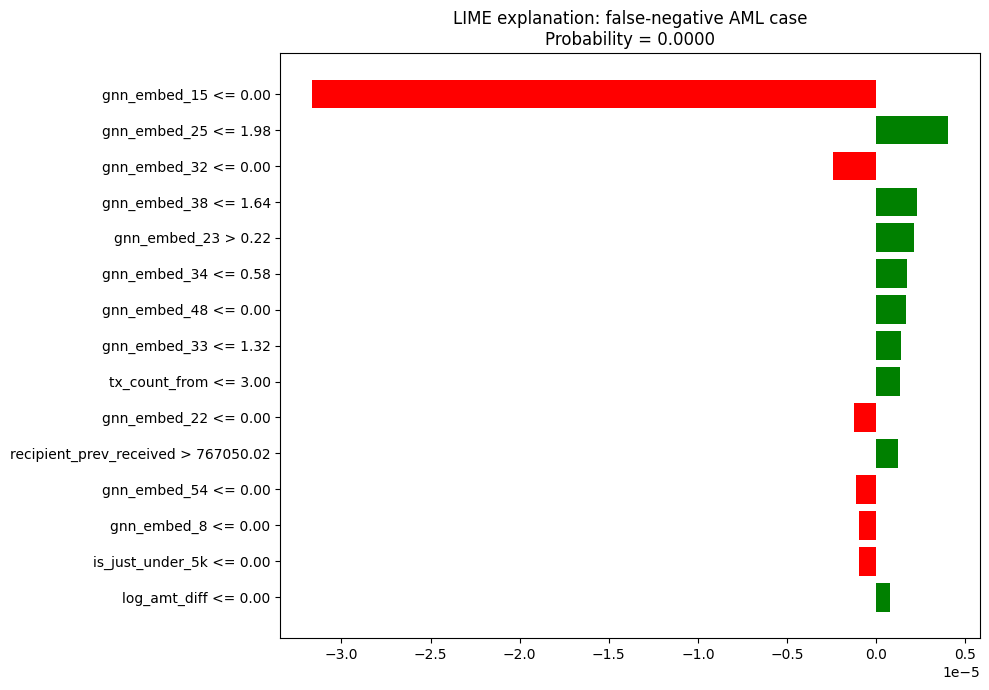

In [33]:
false_negative_idx = np.where(
    (ytest_array == 1) &
    (y_test_prob_final < best_threshold)
)[0]

print("False negatives available:", len(false_negative_idx))

row_idx = false_negative_idx[0]

print("Selected false-negative row:", row_idx)
print("True label:", int(ytest_array[row_idx]))
print("Predicted AML probability:", float(y_test_prob_final[row_idx]))

exp_fn = lime_explainer.explain_instance(
    data_row=X_test_final[row_idx].astype(np.float32),
    predict_fn=hybrid_lstm.predict_proba,
    labels=(1,),
    num_features=15,
    num_samples=3000
)

for feature_rule, weight in exp_fn.as_list(label=1):
    direction = "Toward AML" if weight > 0 else "Toward legitimate"
    print(f"{weight:+.4f} | {direction:>18} | {feature_rule}")

fig = exp_fn.as_pyplot_figure(label=1)
fig.set_size_inches(10, 7)
plt.title(
    f"LIME explanation: false-negative AML case\n"
    f"Probability = {y_test_prob_final[row_idx]:.4f}"
)
plt.tight_layout()
plt.show()

In [34]:
del lime_explainer
del X_lime_background
gc.collect()

4474

SHAP ANALYSIS
Computing SHAP values on 10,000 test samples...
Done.


TOP 20 FEATURES BY SHAP
                   Feature  MeanAbsSHAP
              gnn_embed_25     0.761093
              gnn_embed_38     0.704838
              gnn_embed_23     0.611492
               gnn_embed_4     0.607388
              gnn_embed_41     0.467993
              gnn_embed_33     0.425531
              gnn_embed_46     0.370765
              gnn_embed_35     0.344929
              gnn_embed_34     0.309145
              gnn_embed_42     0.290308
              gnn_embed_61     0.224871
              gnn_embed_15     0.123444
              gnn_embed_19     0.069546
               gnn_embed_8     0.067848
counterparty_revisit_count     0.062547
              gnn_embed_20     0.057586
               gnn_embed_5     0.057572
       log_amount_received     0.055791
           lstm_seq_emb_12     0.055732
              gnn_embed_55     0.051599

Generating SHAP Summary Plot...


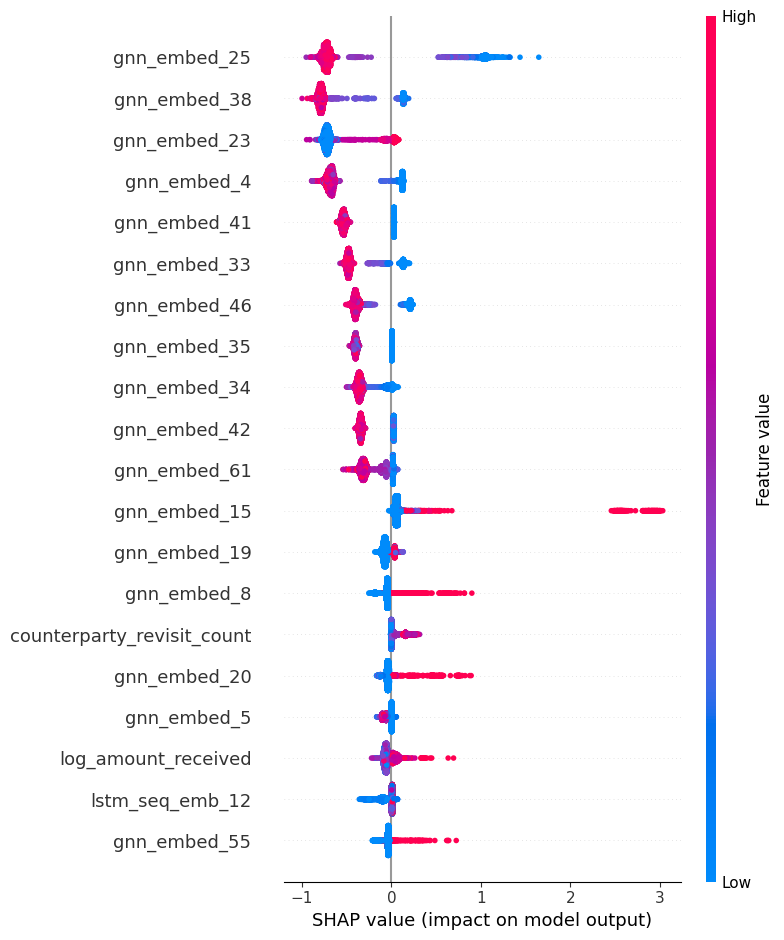

In [35]:
# ============================================================
# SHAP ANALYSIS
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("SHAP ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Create SHAP Explainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(hybrid_lstm)

# ------------------------------------------------------------
# Use a subset for speed
# ------------------------------------------------------------

N_SAMPLES = 10000

sample_size = min(
    N_SAMPLES,
    len(X_test_final)
)

rng = np.random.default_rng(42)

sample_idx = rng.choice(
    len(X_test_final),
    sample_size,
    replace=False
)

X_sample = X_test_final[sample_idx]

print(f"Computing SHAP values on {sample_size:,} test samples...")

# ------------------------------------------------------------
# Compute SHAP Values
# ------------------------------------------------------------

shap_values = explainer.shap_values(X_sample)

print("Done.")

# ------------------------------------------------------------
# Mean Absolute SHAP
# ------------------------------------------------------------

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({

    "Feature": all_feature_names_final,

    "MeanAbsSHAP": mean_abs_shap

})

shap_importance = (
    shap_importance
    .sort_values(
        "MeanAbsSHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Print Top 20
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("TOP 20 FEATURES BY SHAP")
print("=" * 70)

print(
    shap_importance
    .head(20)
    .to_string(index=False)
)

# ------------------------------------------------------------
# SHAP Beeswarm Plot
# ------------------------------------------------------------

print("\nGenerating SHAP Summary Plot...")

plt.figure(figsize=(12,8))

shap.summary_plot(

    shap_values,

    X_sample,

    feature_names=all_feature_names_final,

    max_display=20,

    show=False

)